In [1]:
import os.path, time
import onnxruntime as ort
import pandas as pd
import numpy as np

from utils.dataset import load_dataset_v2, create_lstm_dataset
from tqdm.notebook import tqdm

In [2]:
model = ort.InferenceSession('lstm_model.onnx')

In [3]:
file_name_list = os.listdir(os.path.join('data', 'ver_2'))
file_path_list = []

for file_name in file_name_list:
    file_path_list.append(os.path.join('data', 'ver_2', file_name))

start_time = time.strftime('%Y%m%d-%H%M%S', time.localtime(time.time()))

dataset = load_dataset_v2(file_path_list)
time_dt_arr = np.concatenate([np.array([0]), np.diff(dataset['time(s)'].to_numpy())])
dataset = pd.concat([pd.DataFrame(time_dt_arr, columns=['time_diff(s)']), dataset], axis=1)

loading dataset...:   0%|          | 0/84 [00:00<?, ?it/s]

In [4]:
extra_column_name_list = ['pressure_1(bar)', 'main_pressure(bar)']
extra_feature = pd.DataFrame()

for col_name in extra_column_name_list:
    extra_feature['diff_'+col_name] = np.diff(dataset[col_name].to_numpy())

dataset = pd.concat([dataset, extra_feature], axis=1)

In [5]:
feature_col_name_list = ['pressure_1(bar)', 'main_pressure(bar)', 'diff_pressure_1(bar)', 'diff_main_pressure(bar)']
#feature_col_name_list = ['time_diff(s)', 'pressure_1(bar)', 'main_pressure(bar)']

target_col_name = 'outlet_flowrate(lpm)'

train_data = dataset[dataset['test_case_iter']!=3]
val_data = dataset[dataset['test_case_iter']==3]

train_feature = train_data[feature_col_name_list]
train_feature.reset_index(drop=True, inplace=True)

train_target = pd.DataFrame(train_data[target_col_name])
train_target.reset_index(drop=True, inplace=True)

val_feature = val_data[feature_col_name_list]
val_feature.reset_index(drop=True, inplace=True)

val_target = pd.DataFrame(val_data[target_col_name])
val_target.reset_index(drop=True, inplace=True)

In [7]:
seq_len = 30
pred_distance = 0

train_feature, train_target = create_lstm_dataset(train_data[feature_col_name_list+[target_col_name]].to_numpy(), seq_len=seq_len, pred_distance=pred_distance, target_idx_pos=4)
val_feature, val_target = create_lstm_dataset(val_data[feature_col_name_list+[target_col_name]].to_numpy(), seq_len=seq_len, pred_distance=pred_distance, target_idx_pos=4)

In [9]:
val_feature = val_feature.astype(np.float32)
val_target = val_target.astype(np.float32)

time_list = []

for input_data in tqdm(val_feature):
    t0 = time.time()
    input_data = np.expand_dims(input_data, axis=0)
    pred = model.run(output_names=None, input_feed={'input': input_data})[0][0]
    time_list.append(time.time() - t0)

print('Average inference time per data sequence: {:.3f} seconds'.format(np.mean(time_list)))

  0%|          | 0/746321 [00:00<?, ?it/s]

Average inference time per data sequence: 0.000 seconds


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

(0.0, 5.0)

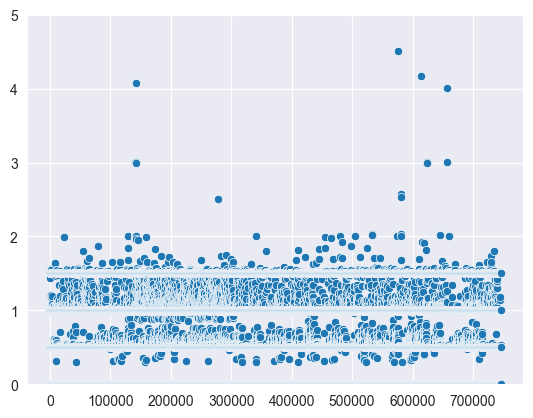

In [14]:
sns.scatterplot(np.array(time_list)*1000)

plt.ylim(0, 5)